# Assignment 1: Environment & First Network

**DATAX504**
ID: 1606009

## Task 1 - Document OpenCode setup
![Opencode Setup](opencode_setup.png)

## Task 2 - Train a 2-layer Dense Network on Synthetic Data

In [56]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt

# Set the random seed
np.random.seed(1606009)                 # My student ID
plt.rcParams['figure.figsize'] = (8, 4) # Size of the plot

X shape: (1000, 2) 
 y shape: (1000, 1)


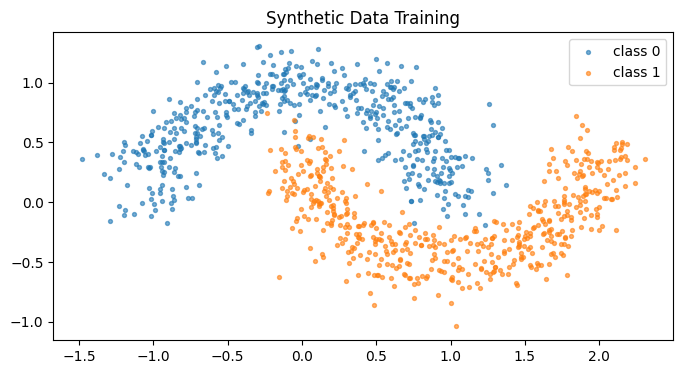

In [57]:
# Generating synthetic dataset
def make_moons(n_samples=1000, noise=0.15):
    """Creates a dataset of two moons
    Args:
        n_samples (int, optional): Number of samples in the dataset. Defaults to 1000.
        noise (float, optional): Scattering of points amount. Defaults to 0.15.
    Returns:
        X, y: (n, 2), (n, 1)
    """
    n = n_samples // 2                                          # Splits the samples into two groups
    theta = np.linspace(0, np.pi, n)                            # Creates an array of floats from 0 to pi evenly spaced by the size of n
    moon1 = np.c_[np.cos(theta), np.sin(theta)]                 # Creates the moon with the cos and sin of theta
    moon2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5]   # Inverted moon that is shifted down by 0.5
    X = np.vstack([moon1, moon2])                               # Vertically stacks the two moons
    X += np.random.randn(*X.shape) * noise                      # Scatters the points horizontally so the data isn't perfect lines
    y = np.vstack([np.zeros((n, 1)), np.ones((n, 1))])          # 
    return X.astype(np.float32), y.astype(np.float32)           # Returns X and y as float

# Create the dataset
X, y = make_moons()                                 # Doesn't actually need n_samples as matches default
print(f"X shape: {X.shape} \n y shape: {y.shape}")  # Matches the intended shape of X: (n, 2), y: (n, 1)

# Plot dataset
plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], s=8, alpha=0.6, label="class 0") # Scatter plot of moon1
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], s=8, alpha=0.6, label="class 1") # Inverse Scatter plot of moon2 under moon1
plt.legend()                            # Create a legend for the labels
plt.title("Synthetic Data Training")    # Add title
plt.show()                              # Plot the data

In [58]:
# Activation functions
def relu(x):
    return np.maximum(0, x)             # If positive x, if negative 0

def relu_derivitive(x):
    return (x > 0).astype(np.float32)   # If x > 0 then 1 else 0

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500))) 

def sigmoid_derivitive(x):              
    return sigmoid(x) * (1 - sigmoid(x))

In [ ]:
# Network parameters
input_size = 2
hidden_size = 16
output_size = 1
learning_rate = 0.1
epochs = 100

def get_W(rows, cols, multiplier):
    return np.random.randn(rows, cols).astype(np.float32) * multiplier

def get_b(size):
    return np.zeros((1, size), dtype=np.float32)

# Initialise W1, b1, W2, b2
W1 = get_W(input_size, hidden_size, np.sqrt(2 / input_size))
W2 = get_W(hidden_size, output_size, learning_rate)
b1 = get_b(hidden_size)
b2 = get_b(output_size)
# Weights that lead to lowest loss value

total_params = W1.size + b1.size + W2.size + b2.size
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 65


In [60]:
# Forward and backwards passes
def get_Z(x, W, b):
    return x @ W + b

def get_dW(x, dZ):
    return x.T @ dZ

def get_dA(W, dZ):
    return dZ @ W.T

def get_db(dZ):
    return np.sum(dZ, axis=0, keepdims=True)

def split_cache(cache):
    return cache["A1"], cache["A2"], cache["Z1"]

def forward(X, W1, b1, W2, b2):
    Z1 = get_Z(X, W1, b1)       # XW1+b1
    A1 = relu(Z1)
    Z2 = get_Z(A1, W2, b2)      # XW2+b2
    A2 = sigmoid(Z2)
    return {"Z1": Z1, "A1": A1, "A2": A2}

def backward(X, y, cache, W2):
    m = X.shape[0]
    A1, A2, Z1 = split_cache(cache)
    # TODO: complete back propogation
    dZ2 = (A2 - y) / m      # Sigmoidal with binary cross entropy
    dW2 = get_dW(A1, dZ2)
    db2 = get_db(dZ2)
    dA1 = get_dA(W2, dZ2)
    dZ1 = dA1 * relu_derivitive(Z1)
    dW1 = get_dW(X, dZ1)
    db1 = get_db(dZ1)
    return dW1, db1, dW2, db2

def compute_loss(y, A2):
    eps = 1e-8
    return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))
    

## Task 3 - Plot Training Loss Over 100 Epochs

In [61]:
# Debug issue:
print("X:", X.shape)
print("W1:", W1.shape, "b1:", b1.shape)
print("W2:", W2.shape, "b2:", b2.shape)

X: (1000, 2)
W1: (2, 16) b1: (1, 16)
W2: (16, 1) b2: (1, 1)


In [62]:
loss_history = []

for epoch in range(epochs):
    cache = forward(X, W1, b1, W2, b2)
    loss = compute_loss(y, cache["A2"])
    loss_history.append(loss)
    dW1, db1, dW2, db2 = backward(X, y, cache, W2)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}, loss = {loss:4f}")
        
final_loss = loss_history[-1]
print(f"Final loss: {final_loss:4f}")

Epoch   0, loss = 0.697884
Epoch  20, loss = 0.414784
Epoch  40, loss = 0.357973
Epoch  60, loss = 0.333565
Epoch  80, loss = 0.319103
Final loss: 0.309344


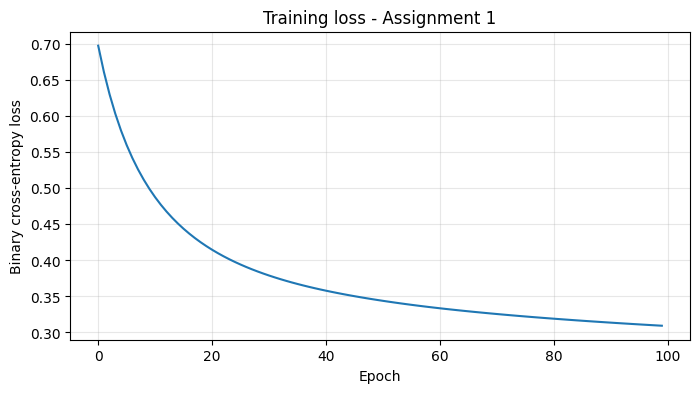

In [63]:
# Plotting loss
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss - Assignment 1")
plt.grid(True, alpha=0.3)
plt.show()

## Task 4 - OpenCode Use Reflection
I used opencode to connect the ollama model locally. It requires a paid subsription to use it over the API. So instead with the help of the Big Pickle model I managed to set up a json file that connects to ollama model qwen2.5-coder:7b. This ended up being too large for my RAM so I moved again to qwen3:1.7b.

Initially I recieved an error from the forward propagation as the dimensions missmatched. So I used to model to determine that I had made an error in the order of the sizes, I had accientally created a 3D grid instead of a 2D grid so the shape of the parameters created an error. I also made a small error where I tried to retrieve A1 and A2 from the cache at once rather than seperately, which required multiple iterations of conversation to identify the error.

The primary issue I am having with opencode is during planning it will often disregard my prompt and replaces it with the "do not edit" system prompt. This requires starting a new "chat" each time as there is no going back from the model reading its own instructions as prompts.